In [1]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [2]:
# ── 1. CHARGER SPLITS ENCODÉS ──────────────────
with open('splits_encoded.pkl', 'rb') as f:
    splits_encoded = pickle.load(f)

print("✅ Splits encodés chargés")

✅ Splits encodés chargés


In [3]:
# ── 2. COLONNES NUMÉRIQUES ─────────────────────
NUM_COLS = {
    'Type_Of_Failure' : [
        'Hour',
        'Reaction Time (min)',
    ],
    'Serial_Device'   : [
        'Hour',
        'Reaction Time (min)',
    ],
    'Down_Time'       : [
        'Hour',
        'Reaction Time (min)',
        'Waiting Time (min)',
    ],
    'When_Panne'      : [
        'Last_Hour',
        'Last_Down_Time',
        'Last_Reaction_Time',
        'Last_Waiting_Time',
        'Mean_Down_Time',
        'Mean_Time_Between',
        'Nb_Pannes_Avant',
    ],
}

scalers_std = {}
scalers_mm  = {}
splits_scaled = {}

for name, s in splits_encoded.items():
    print(f"\n--- Standardisation {name} ---")

    Xtr = s['Xtr'].copy()
    Xte = s['Xte'].copy()

    # Colonnes à standardiser
    num = [c for c in NUM_COLS.get(name, [])
           if c in Xtr.columns]

    if not num:
        print(f"  ⚠️ Aucune colonne numérique trouvée")
        splits_scaled[name] = s.copy()
        splits_scaled[name]['Xtr_scaled'] = Xtr
        splits_scaled[name]['Xte_scaled'] = Xte
        continue

    print(f"  Colonnes : {num}")

    # ── StandardScaler ──────────────────────────
    sc_std = StandardScaler()
    Xtr_std = Xtr.copy()
    Xte_std = Xte.copy()

    # FIT sur train — TRANSFORM sur test
    Xtr_std[num] = sc_std.fit_transform(Xtr[num])
    Xte_std[num] = sc_std.transform(Xte[num])

    # ── MinMaxScaler ────────────────────────────
    sc_mm  = MinMaxScaler()
    Xtr_mm = Xtr.copy()
    Xte_mm = Xte.copy()

    Xtr_mm[num] = sc_mm.fit_transform(Xtr[num])
    Xte_mm[num] = sc_mm.transform(Xte[num])

    scalers_std[name] = sc_std
    scalers_mm[name]  = sc_mm

    splits_scaled[name] = {
        **s,
        # Standard
        'Xtr_scaled'    : Xtr_std,
        'Xte_scaled'    : Xte_std,
        # MinMax
        'Xtr_scaled_mm' : Xtr_mm,
        'Xte_scaled_mm' : Xte_mm,
        'num_cols'      : num,
    }

    # Stats avant/après
    print(f"\n  Avant standardisation :")
    print(f"  {Xtr[num].describe().round(2)}")
    print(f"\n  Après StandardScaler :")
    print(f"  {Xtr_std[num].describe().round(2)}")
    print(f"\n  Après MinMaxScaler :")
    print(f"  {Xtr_mm[num].describe().round(2)}")




--- Standardisation Type_Of_Failure ---
  Colonnes : ['Hour', 'Reaction Time (min)']

  Avant standardisation :
             Hour  Reaction Time (min)
count  14658.00             14658.00
mean      11.82                56.87
std        6.77               356.68
min        0.00                 0.02
25%        6.00                 0.05
50%       12.00                 0.08
75%       17.00                 0.30
max       23.00              8948.42

  Après StandardScaler :
             Hour  Reaction Time (min)
count  14658.00             14658.00
mean      -0.00                 0.00
std        1.00                 1.00
min       -1.75                -0.16
25%       -0.86                -0.16
50%        0.03                -0.16
75%        0.77                -0.16
max        1.65                24.93

  Après MinMaxScaler :
             Hour  Reaction Time (min)
count  14658.00             14658.00
mean       0.51                 0.01
std        0.29                 0.04
min        0.00  

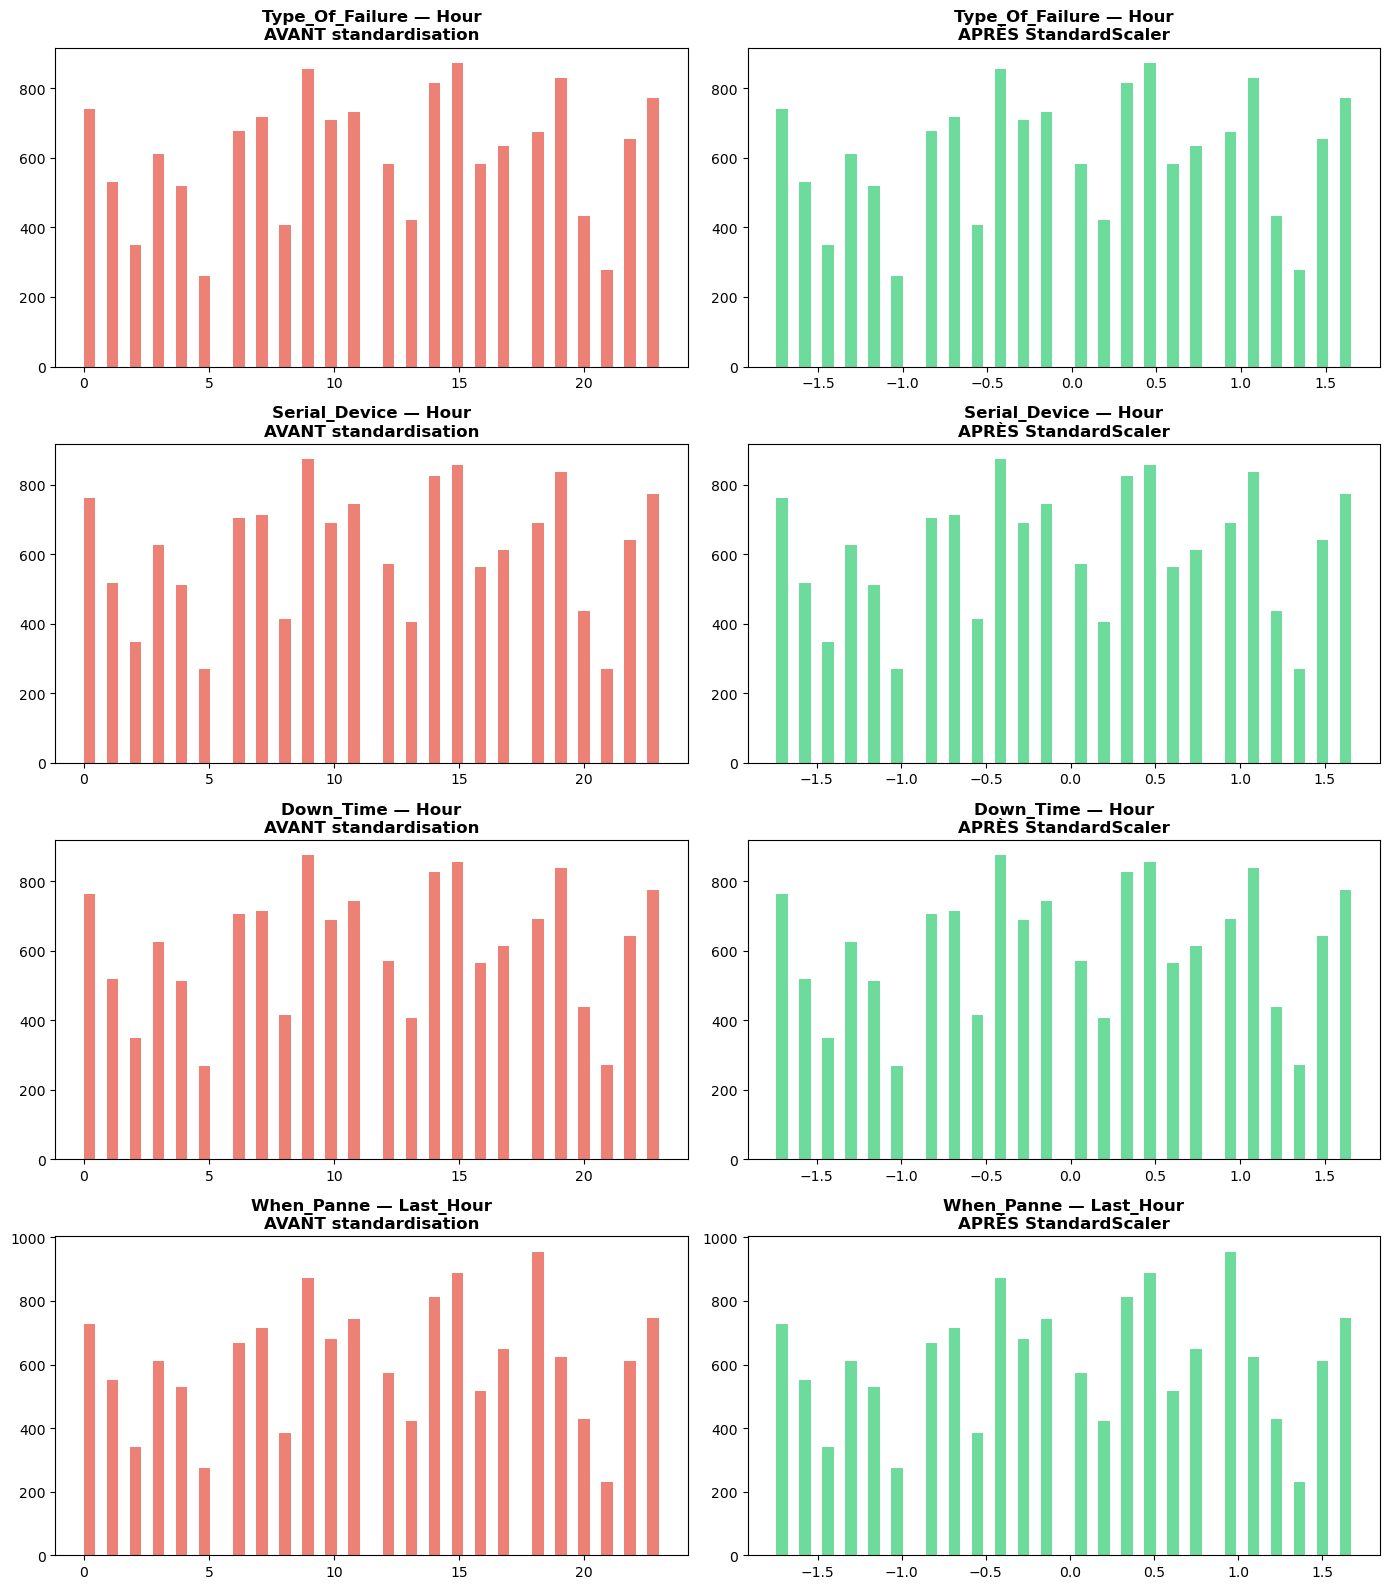

In [4]:
# ── 3. VISUALISATION AVANT/APRÈS ───────────────
fig, axes = plt.subplots(
    len(splits_scaled), 2,
    figsize=(14, len(splits_scaled) * 4))
axes = axes if len(splits_scaled) > 1 else [axes]

for i, (name, s) in enumerate(splits_scaled.items()):
    if 'num_cols' not in s:
        continue
    num = s['num_cols']
    col = num[0]  # Première colonne numérique

    # Avant
    axes[i][0].hist(
        s['Xtr'][col].dropna(),
        bins=50, color='#e74c3c', alpha=0.7)
    axes[i][0].set_title(
        f'{name} — {col}\nAVANT standardisation',
        fontweight='bold')

    # Après
    axes[i][1].hist(
        s['Xtr_scaled'][col].dropna(),
        bins=50, color='#2ecc71', alpha=0.7)
    axes[i][1].set_title(
        f'{name} — {col}\nAPRÈS StandardScaler',
        fontweight='bold')

plt.tight_layout()
plt.savefig('standardisation_comparison.png', dpi=150)
plt.show()



In [5]:
# ── 4. SAUVEGARDER ─────────────────────────────
with open('splits_scaled.pkl', 'wb') as f:
    pickle.dump(splits_scaled, f)
with open('scalers_std.pkl', 'wb') as f:
    pickle.dump(scalers_std, f)
with open('scalers_mm.pkl', 'wb') as f:
    pickle.dump(scalers_mm, f)

print("\n" + "="*45)
print("  RÉSUMÉ STANDARDISATION")
print("="*45)
for name, s in splits_scaled.items():
    print(f"\n  {name} :")
    print(f"    Xtr_scaled : {s['Xtr_scaled'].shape}")
    print(f"    Xte_scaled : {s['Xte_scaled'].shape}")
    if 'num_cols' in s:
        print(f"    Cols std   : {s['num_cols']}")

print("\n✅ splits_scaled.pkl  sauvegardé")
print("✅ scalers_std.pkl    sauvegardé")
print("✅ scalers_mm.pkl     sauvegardé")


  RÉSUMÉ STANDARDISATION

  Type_Of_Failure :
    Xtr_scaled : (14658, 6)
    Xte_scaled : (3665, 6)
    Cols std   : ['Hour', 'Reaction Time (min)']

  Serial_Device :
    Xtr_scaled : (14658, 7)
    Xte_scaled : (3665, 7)
    Cols std   : ['Hour', 'Reaction Time (min)']

  Down_Time :
    Xtr_scaled : (14658, 9)
    Xte_scaled : (3665, 9)
    Cols std   : ['Hour', 'Reaction Time (min)', 'Waiting Time (min)']

  When_Panne :
    Xtr_scaled : (14558, 13)
    Xte_scaled : (3640, 13)
    Cols std   : ['Last_Hour', 'Last_Down_Time', 'Last_Reaction_Time', 'Last_Waiting_Time', 'Mean_Down_Time', 'Mean_Time_Between', 'Nb_Pannes_Avant']

✅ splits_scaled.pkl  sauvegardé
✅ scalers_std.pkl    sauvegardé
✅ scalers_mm.pkl     sauvegardé
